In [100]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
df=pd.read_csv("eci_results_tamilnadu_2026.csv")

In [101]:
df.head()

,Code,Constituency,Candidate,Party,EVM Votes,Postal Votes,Total Votes,% Votes,Round,Last Updated Time,Last Updated Date
0,S221,GUMMIDIPOONDI - 1,T.J.GOVINDARAJAN,Dravida Munnetra Kazhagam,61922,570,62492,26.88,26/26,11:27 PM,04/05/2026
1,S221,GUMMIDIPOONDI - 1,SUDHAKAR.V,All India Anna Dravida Munnetra Kazhagam,65894,481,66375,28.55,26/26,11:27 PM,04/05/2026
2,S221,GUMMIDIPOONDI - 1,M.JAGADEESAN,Bahujan Samaj Party,695,2,697,0.30,26/26,11:27 PM,04/05/2026
3,S221,GUMMIDIPOONDI - 1,"R.SRIDAR. B.L.,",Naam Tamilar Katchi,4707,49,4756,2.05,26/26,11:27 PM,04/05/2026
4,S221,GUMMIDIPOONDI - 1,SDK SANKAR,Aanaithinthiya Jananayaka Pathukappu Kazhagam,593,6,599,0.26,26/26,11:27 PM,04/05/2026


In [102]:
df.columns=df.columns.str.lower()

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4257 entries, 0 to 4256
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   code               4257 non-null   object 
 1   constituency       4257 non-null   object 
 2   candidate          4257 non-null   object 
 3   party              4257 non-null   object 
 4   evm votes          4257 non-null   int64  
 5   postal votes       4257 non-null   int64  
 6   total votes        4257 non-null   int64  
 7   % votes            4257 non-null   float64
 8   round              4257 non-null   object 
 9   last updated time  4257 non-null   object 
 10  last updated date  4257 non-null   object 
dtypes: float64(1), int64(3), object(7)
memory usage: 366.0+ KB


In [104]:
df.duplicated().sum()

np.int64(0)

In [105]:
df.isna().sum()

code                 0
constituency         0
candidate            0
party                0
evm votes            0
postal votes         0
total votes          0
% votes              0
round                0
last updated time    0
last updated date    0
dtype: int64

In [106]:
df.drop(columns=['last updated time','last updated date'],inplace=True)

In [107]:
df.head()

,code,constituency,candidate,party,evm votes,postal votes,total votes,% votes,round
0,S221,GUMMIDIPOONDI - 1,T.J.GOVINDARAJAN,Dravida Munnetra Kazhagam,61922,570,62492,26.88,26/26
1,S221,GUMMIDIPOONDI - 1,SUDHAKAR.V,All India Anna Dravida Munnetra Kazhagam,65894,481,66375,28.55,26/26
2,S221,GUMMIDIPOONDI - 1,M.JAGADEESAN,Bahujan Samaj Party,695,2,697,0.30,26/26
3,S221,GUMMIDIPOONDI - 1,"R.SRIDAR. B.L.,",Naam Tamilar Katchi,4707,49,4756,2.05,26/26
4,S221,GUMMIDIPOONDI - 1,SDK SANKAR,Aanaithinthiya Jananayaka Pathukappu Kazhagam,593,6,599,0.26,26/26


In [108]:
df.describe()

,evm votes,postal votes,total votes,% votes
count,4257.000000,4257.000000,4257.000000,4257.000000
mean,11463.899930,122.598778,11586.498708,5.496855
std,25535.983956,283.467189,25786.727983,11.918995
min,2.000000,0.000000,2.000000,0.000000
25%,121.000000,1.000000,122.000000,0.060000
50%,269.000000,2.000000,271.000000,0.130000
75%,1021.000000,21.000000,1031.000000,0.490000
max,219807.000000,2399.000000,220382.000000,58.890000


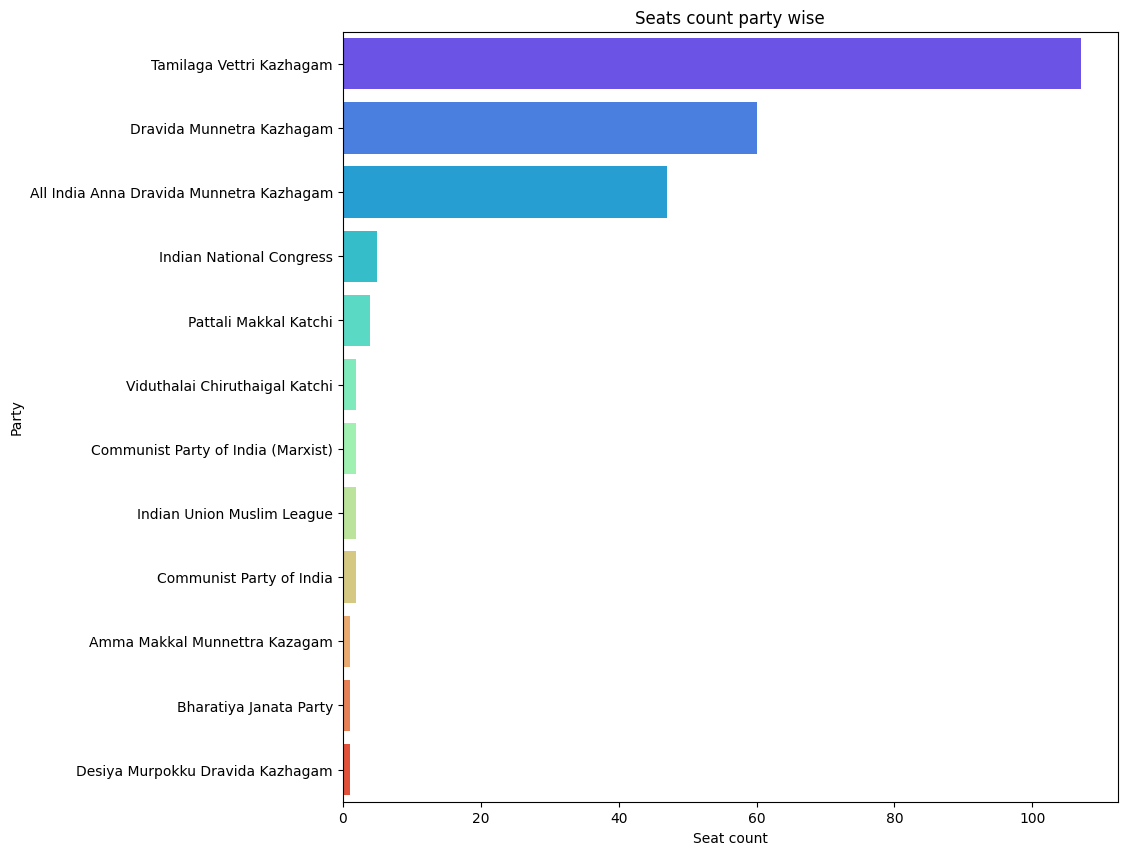

In [109]:
# seat won per party in number 

winners_idx=df.groupby('constituency')['total votes'].idxmax()
winner=df.loc[winners_idx,['party']]['party'].value_counts()
plt.figure(figsize=(10,10))
sns.barplot(y=winner.index,x=winner.values,palette='rainbow')
plt.title("Seats count party wise")
plt.xlabel("Seat count")
plt.ylabel("Party")
plt.show()

Text(0.5, 1.0, 'seat share in percentage by Party')

<Figure size 800x800 with 0 Axes>

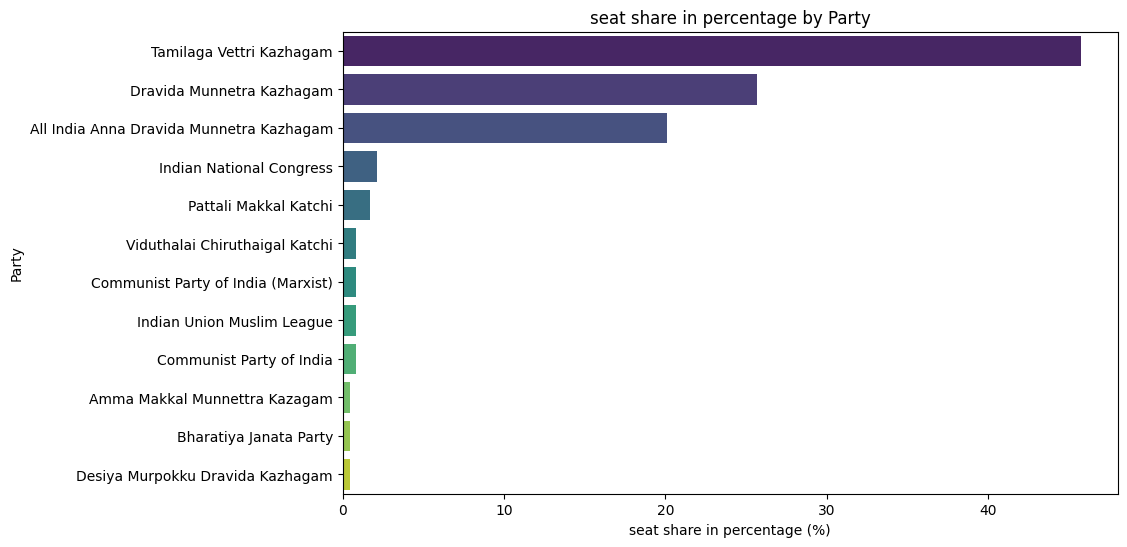

In [110]:
# seat share in percentage
plt.figure(figsize=(8,8))
seat_percentage=winner/winner.sum()*100
plt.figure(figsize=(10,6))

sns.barplot(
    x=seat_percentage.values,
    y=seat_percentage.index,
    palette='viridis'
)

plt.xlabel("seat share in percentage (%)")
plt.ylabel("Party")
plt.title("seat share in percentage by Party")

Text(0, 0.5, 'parties')

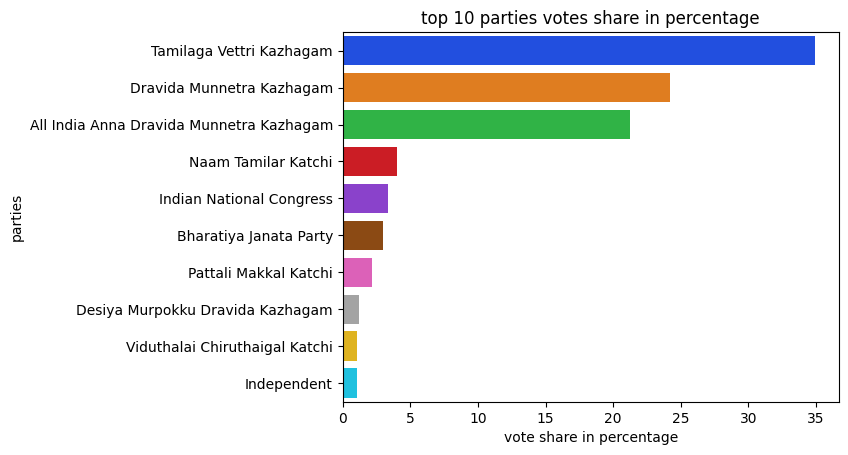

In [111]:
# top ten parties votes percentage but in total
votes=df.groupby('party')['total votes'].sum().sort_values(ascending=False)
votes_per=((votes/votes.sum())*100).head(10)
sns.barplot(y=votes_per.index,x=votes_per.values,palette='bright')
plt.title("top 10 parties votes share in percentage")
plt.xlabel("vote share in percentage")
plt.ylabel("parties")

Text(0, 0.5, 'constituencies')

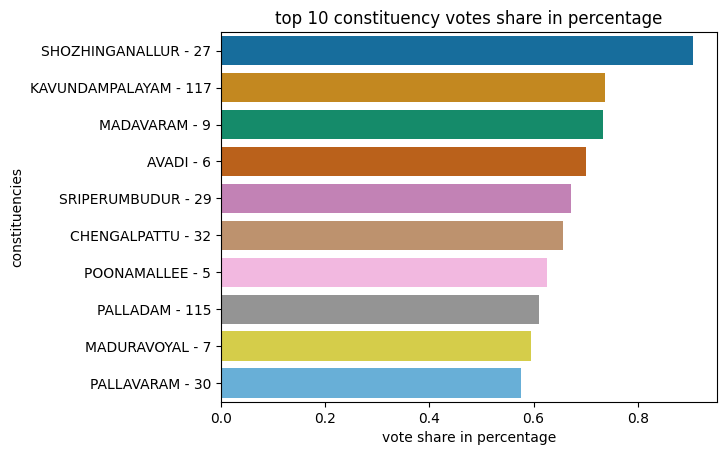

In [112]:
# constituency wise votes share 
con_votes=df.groupby('constituency')['total votes'].sum().sort_values(ascending=False)
con_votes_per=((con_votes/con_votes.sum())*100).head(10)
sns.barplot(y=con_votes_per.index,x=con_votes_per.values,palette='colorblind')
plt.title("top 10 constituency votes share in percentage")
plt.xlabel("vote share in percentage")
plt.ylabel("constituencies")


Text(0.5, 1.0, 'vote distribution of top two parties of most vote share constituency')

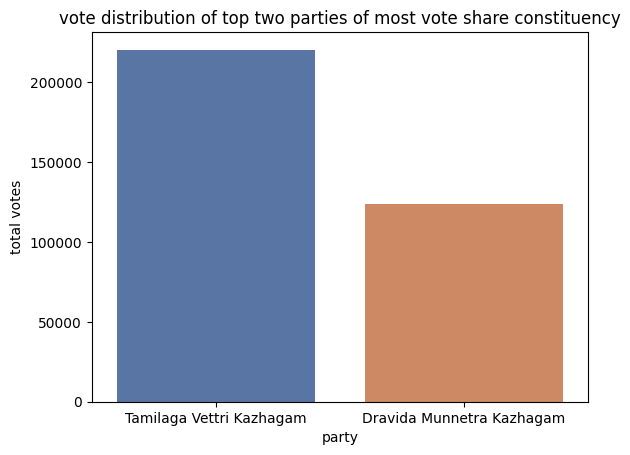

In [113]:
shoz=df[df['constituency']=='SHOZHINGANALLUR - 27']
shoz_sort=shoz.sort_values(by='total votes',ascending=False).head(2)
sns.barplot(x='party',y='total votes',data=shoz_sort,palette="deep")
plt.title("vote distribution of top two parties of most vote share constituency")

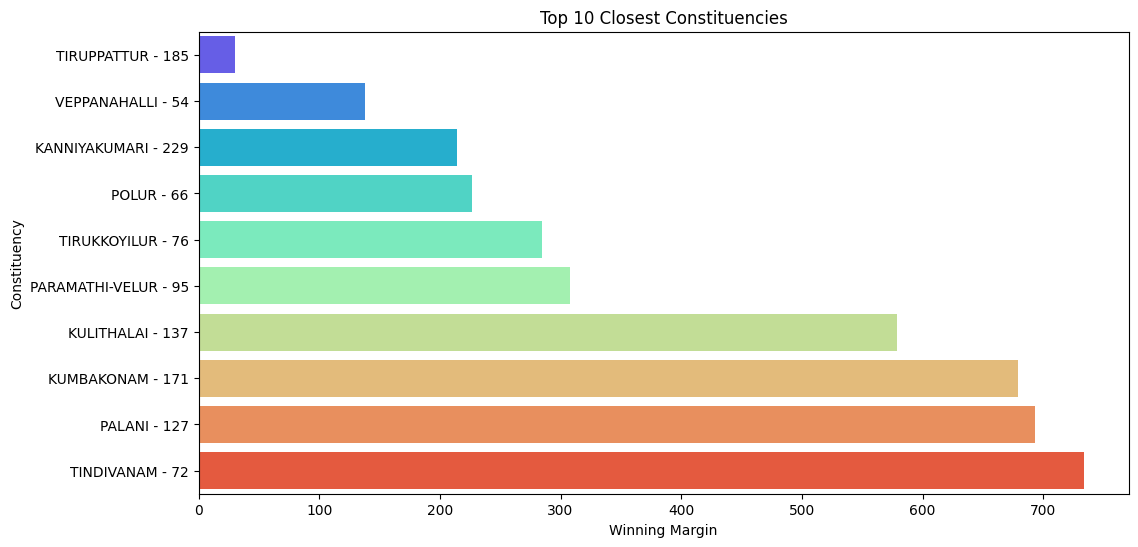

In [114]:
# top ten lowest margins to win constituecy wise 
margins = []

for constituency, group in df.groupby('constituency'):
    top2 = group.nlargest(2, 'total votes')

    if len(top2) == 2:
        margin = top2.iloc[0]['total votes'] - top2.iloc[1]['total votes']
        margins.append([constituency, margin])

margin_df = pd.DataFrame(margins, columns=['constituency', 'margin'])

lowest_margin = margin_df.nsmallest(10, 'margin')
plt.figure(figsize=(12,6))

sns.barplot(
    data=lowest_margin,
    x='margin',
    y='constituency',
    palette='rainbow'
)

plt.title('Top 10 Closest Constituencies')
plt.xlabel('Winning Margin')
plt.ylabel('Constituency')
plt.show()

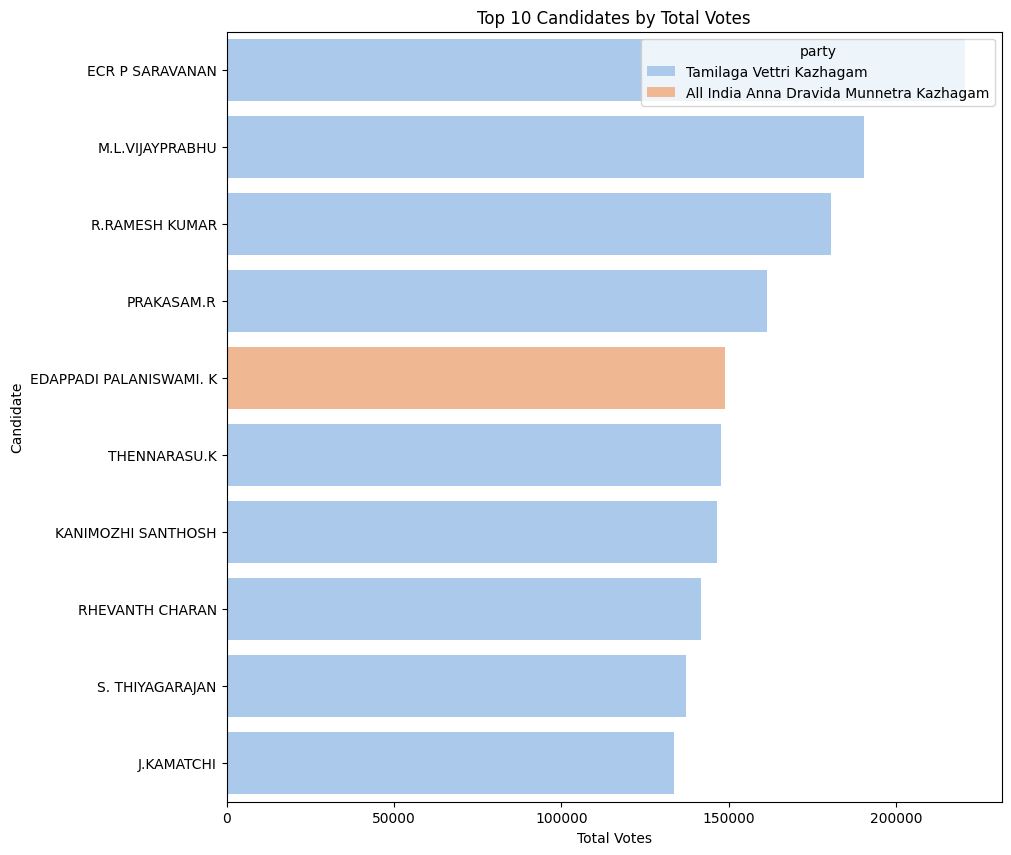

In [115]:
candidates_votes=df.sort_values(by='total votes',ascending=False).head(10)
plt.figure(figsize=(10,10))
sns.barplot(y='candidate',x='total votes',hue='party',data=candidates_votes,palette='pastel',legend='full')
plt.title("Top 10 Candidates by Total Votes")
plt.xlabel("Total Votes")
plt.ylabel("Candidate")
plt.show()

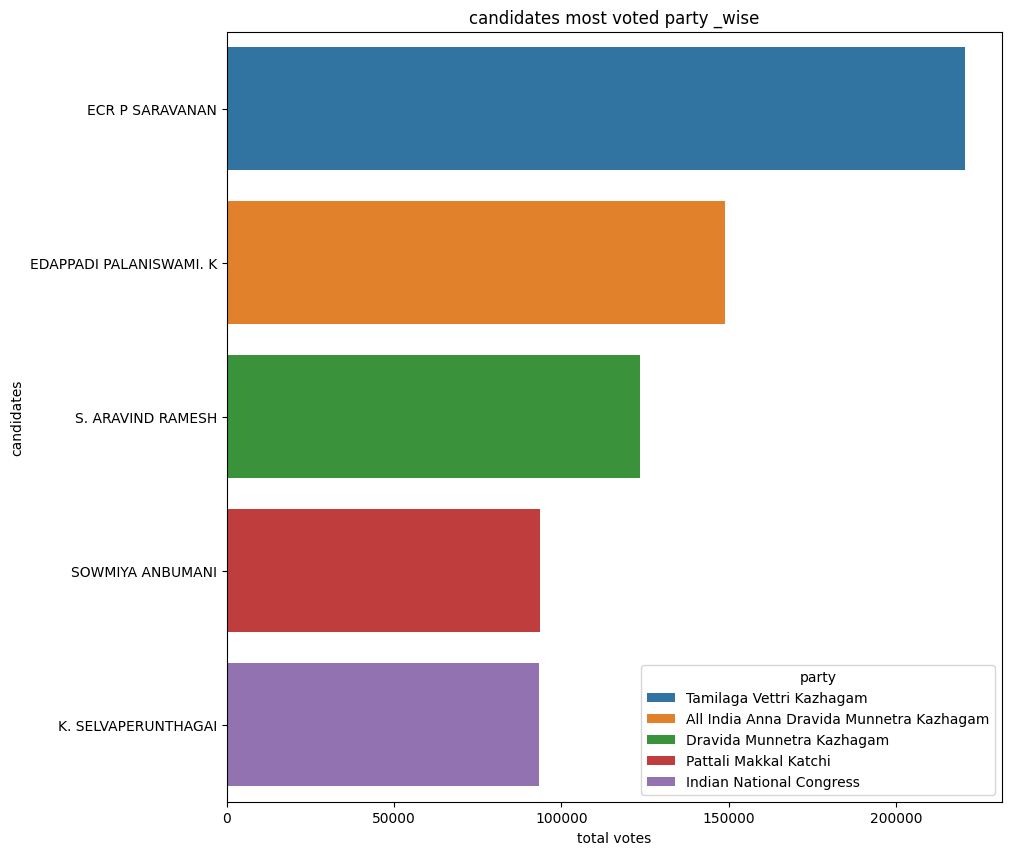

In [116]:
can=df.loc[df.groupby('party')['total votes'].idxmax(),
       ['party','candidate','total votes']].sort_values(
           by='total votes', ascending=False
       ).head()
plt.figure(figsize=(10,10))
sns.barplot(y='candidate',x='total votes',hue='party',data=can)
plt.title("candidates most voted party _wise")
plt.xlabel("total votes")
plt.ylabel("candidates")
plt.show()

In [117]:
df.corr(numeric_only=True)

,evm votes,postal votes,total votes,% votes
evm votes,1.000000,0.883354,0.999987,0.975659
postal votes,0.883354,1.000000,0.885757,0.889038
total votes,0.999987,0.885757,1.000000,0.975945
% votes,0.975659,0.889038,0.975945,1.000000
